In [ ]:
# NOTHING OS — Notebook Styling
from IPython.display import HTML, display

display(HTML('''
<style>
  @import url('https://fonts.googleapis.com/css2?family=Share+Tech+Mono&family=Space+Mono&display=swap');

  :root {
    --nothing-black:   #0A0A0A;
    --nothing-surface: #111111;
    --nothing-border:  #2A2A2A;
    --nothing-white:   #F5F5F5;
    --nothing-gray-1:  #CCCCCC;
    --nothing-gray-2:  #888888;
    --nothing-gray-3:  #555555;
    --nothing-red:     #FF1C1C;
    --font-ndot:       'Share Tech Mono', monospace;
    --font-body:       'Space Mono', monospace;
  }

  body, .jp-Notebook {
    background: var(--nothing-black) !important;
    font-family: var(--font-body) !important;
  }

  .jp-Cell { border-radius: 0 !important; }

  .jp-InputArea-editor, .jp-CodeCell .jp-Editor {
    background: var(--nothing-surface) !important;
    border: 1px solid var(--nothing-border) !important;
    border-radius: 0 !important;
    font-family: var(--font-body) !important;
    font-size: 12px !important;
  }

  .jp-OutputArea-output {
    background: #0D0D0D !important;
    border-left: 2px solid var(--nothing-border) !important;
    font-family: var(--font-body) !important;
    color: var(--nothing-gray-1) !important;
    font-size: 12px !important;
  }

  .jp-MarkdownOutput h1, .jp-MarkdownOutput h2, .jp-MarkdownOutput h3 {
    font-family: var(--font-ndot) !important;
    color: var(--nothing-white) !important;
    letter-spacing: 0.1em;
    text-transform: uppercase;
    border-bottom: 1px solid var(--nothing-border) !important;
    padding-bottom: 8px;
  }

  .jp-MarkdownOutput h1 { font-size: 22px !important; }
  .jp-MarkdownOutput h2 { font-size: 16px !important; }
  .jp-MarkdownOutput h3 { font-size: 13px !important; color: var(--nothing-gray-2) !important; }

  .jp-MarkdownOutput p, .jp-MarkdownOutput li {
    color: var(--nothing-gray-2) !important;
    font-family: var(--font-body) !important;
    font-size: 12px !important;
  }

  .jp-MarkdownOutput code {
    background: var(--nothing-surface) !important;
    color: var(--nothing-red) !important;
    border: 1px solid var(--nothing-border) !important;
    border-radius: 0 !important;
    padding: 1px 5px;
    font-size: 11px !important;
  }

  .jp-Toolbar {
    background: #070707 !important;
    border-bottom: 1px solid var(--nothing-border) !important;
  }
</style>
'''))

# And configure matplotlib globally:
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor': '#0A0A0A', 'axes.facecolor': '#111111',
    'axes.edgecolor': '#2A2A2A', 'axes.labelcolor': '#888888',
    'text.color': '#888888', 'xtick.color': '#555555', 'ytick.color': '#555555',
    'grid.color': '#2A2A2A', 'grid.linewidth': 0.5, 'grid.linestyle': ':',
    'axes.grid': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'monospace', 'figure.titlesize': 11,
    'legend.facecolor': '#111111', 'legend.edgecolor': '#2A2A2A',
    'lines.linewidth': 1.5, 'axes.titlesize': 10, 'axes.labelsize': 9,
    'axes.titlecolor': '#F5F5F5',
})

NOTHING_RED    = '#FF1C1C'
NOTHING_WHITE  = '#F5F5F5'
NOTHING_GRAY   = '#888888'
NOTHING_DIM    = '#555555'
NOTHING_MUTED  = '#3A3A3A'


# Task 4: SHAP Explainability and Model Interpretation

In this notebook, we analyze the Temporal Fusion Transformer (TFT) to understand its decision-making process. We use two levels of interpretability:
1. **TFT Native Weights**: Global variable selection and temporal attention.
2. **SHAP (Shapley Additive Explanations)**: Local impact of features on specific predictions.

In [28]:
import os
import pandas as pd
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet

import sys
sys.path.append('..')
from src.data.loader import M5Loader
from src.data.feature_engineering import create_base_features

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. Load Model and Data

In [29]:
# Load best checkpoint
checkpoint_path = "lightning_logs/tft_model/version_4/checkpoints/epoch=4-step=1550.ckpt"
if not os.path.exists(checkpoint_path):
    possible_paths = ["lightning_logs/tft_model", "../notebooks/lightning_logs/tft_model"]
    for base_dir in possible_paths:
        if os.path.exists(base_dir):
            versions = sorted([v for v in os.listdir(base_dir) if v.startswith('version_')], key=lambda x: int(x.split('_')[1]))
            if versions:
                latest_version = versions[-1]
                ckpt_dir = os.path.join(base_dir, latest_version, "checkpoints")
                if os.path.exists(ckpt_dir):
                    ckpts = [f for f in os.listdir(ckpt_dir) if f.endswith('.ckpt')]
                    if ckpts:
                        checkpoint_path = os.path.join(ckpt_dir, ckpts[0])
                        break

model = TemporalFusionTransformer.load_from_checkpoint(checkpoint_path)
model.to(device)
model.eval()
print(f"Model loaded from {checkpoint_path}")

Model loaded from lightning_logs/tft_model/version_4/checkpoints/epoch=4-step=1550.ckpt


In [30]:
# Load data using the project loader
loader = M5Loader(data_dir='../data')
data = loader.load_merged_sample(n_items=100) 
df = create_base_features(data)

# Create time_idx
df['time_idx'] = df['d'].str.extract('(\d+)').astype(int)
df['time_idx'] -= df['time_idx'].min()

# Cast target to float
if 'sales' in df.columns:
    df['sales'] = df['sales'].astype(float)

# Aggressive categorical casting
cat_params = ["static_categoricals", "time_varying_known_categoricals", "time_varying_unknown_categoricals"]
for p in cat_params:
    for col in model.dataset_parameters.get(p, []):
        if col in df.columns:
            df[col] = df[col].fillna("unknown").apply(lambda x: str(x))

# Fill missing reals
for col in model.dataset_parameters.get("time_varying_known_reals", []) + model.dataset_parameters.get("time_varying_unknown_reals", []):
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median() if not df[col].isna().all() else 0)

# Create dataset using model parameters
val_dataset = TimeSeriesDataSet.from_parameters(
    model.dataset_parameters,
    df,
    predict=True,
    stop_randomization=True
)

val_dataloader = val_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)

INFO:src.data.loader:Loading merged sample of 100 items...
INFO:src.data.loader:Loading sales data...
INFO:src.data.loader:Loading calendar data...
INFO:src.data.loader:Loading prices data...


## 2. TFT Native Interpretation
TFT uses built-in Variable Selection Networks (VSN) and Multi-Head Attention.

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


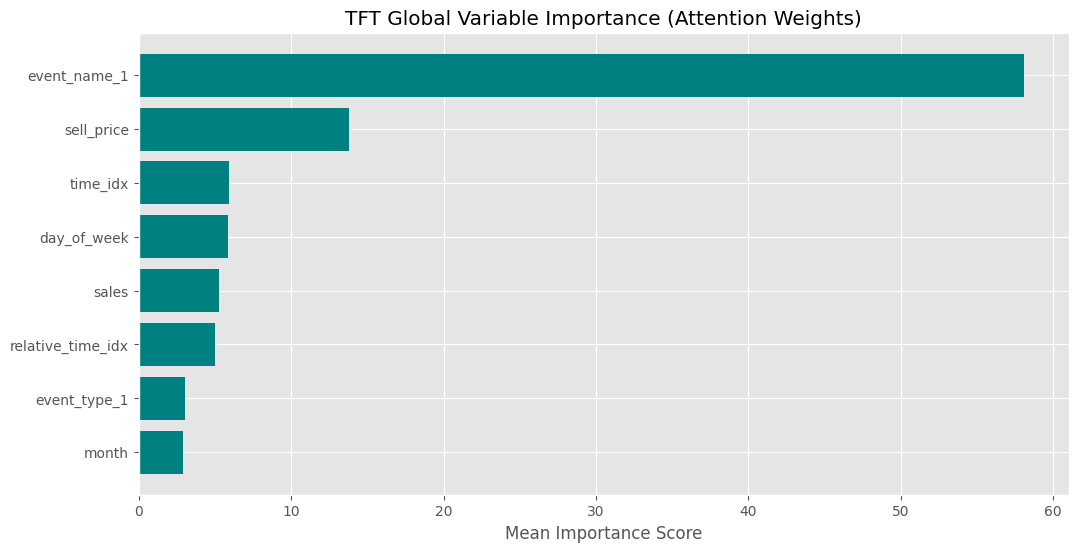

In [31]:
prediction_results = model.predict(val_dataloader, mode="raw", return_x=True)
raw_predictions = prediction_results[0] if isinstance(prediction_results, (tuple, list)) else prediction_results.output

interpretation = model.interpret_output(raw_predictions, reduction="sum")

# 2.1 Global Variable Importance
plt.figure(figsize=(12, 6))
features = model.encoder_variables
importances = interpretation['encoder_variables'].detach().cpu().numpy()

indices = np.argsort(importances)
plt.title("TFT Global Variable Importance (Attention Weights)")
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Mean Importance Score")
plt.show()

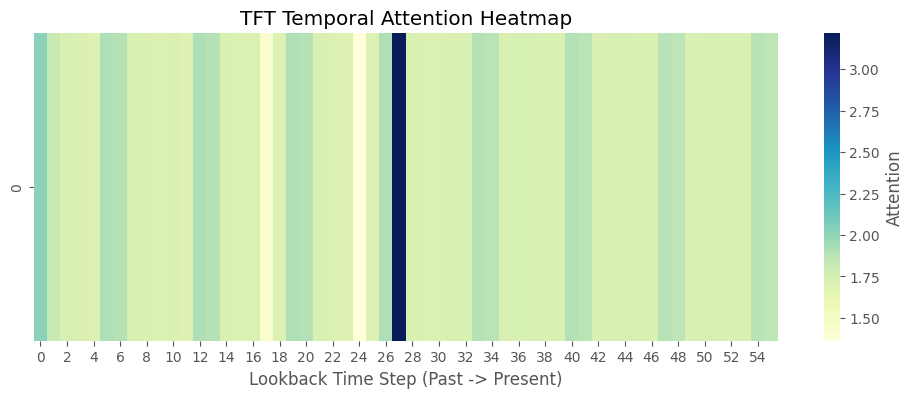

In [32]:
# 2.2 Temporal Attention Heatmap
attention = interpretation["attention"].detach().cpu().numpy()
plt.figure(figsize=(12, 4))
sns.heatmap(attention.reshape(1, -1), cmap="YlGnBu", annot=False, cbar_kws={'label': 'Attention'})
plt.title("TFT Temporal Attention Heatmap")
plt.xlabel("Lookback Time Step (Past -> Present)")
plt.show()

## 3. SHAP Explainability
To use SHAP with TFT, we create a wrapper that handles the model's multi-tensor dictionary input.

In [33]:
class TFTWrapper(torch.nn.Module):
    def __init__(self, model, full_batch):
        super().__init__()
        self.model = model
        self.full_batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in full_batch.items()}
        
    def forward(self, x_cont):
        batch_size = x_cont.shape[0]
        batch = {}
        for k, v in self.full_batch.items():
            if isinstance(v, torch.Tensor):
                if v.shape[0] != batch_size:
                    repeats = [1] * len(v.shape)
                    repeats[0] = (batch_size // v.shape[0]) + 1
                    batch[k] = v.repeat(*repeats)[:batch_size]
                else:
                    batch[k] = v.clone()
            else:
                batch[k] = v
        
        batch["encoder_cont"] = x_cont
        return self.model(batch)["prediction"][:, 0, 3].unsqueeze(-1)

data_batch = next(iter(val_dataloader))[0]
background_reals = data_batch['encoder_cont'][:20].to(device) 
test_reals = data_batch['encoder_cont'][20:23].to(device) 

wrapped_model = TFTWrapper(model, data_batch).to(device)
explainer = shap.GradientExplainer(wrapped_model, background_reals)
shap_values = explainer.shap_values(test_reals)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values_flat = shap_values.reshape(shap_values.shape[0], -1)
test_reals_flat = test_reals.cpu().numpy().reshape(test_reals.shape[0], -1)

feature_names_flat = []
for f in model.reals:
    for t in range(-model.dataset_parameters['max_encoder_length'], 0):
        feature_names_flat.append(f"{f}_lag_{abs(t)}")

# Fix: Calculate expected value manually as GradientExplainer may not store it
with torch.no_grad():
    expected_value = wrapped_model(background_reals).mean().item()

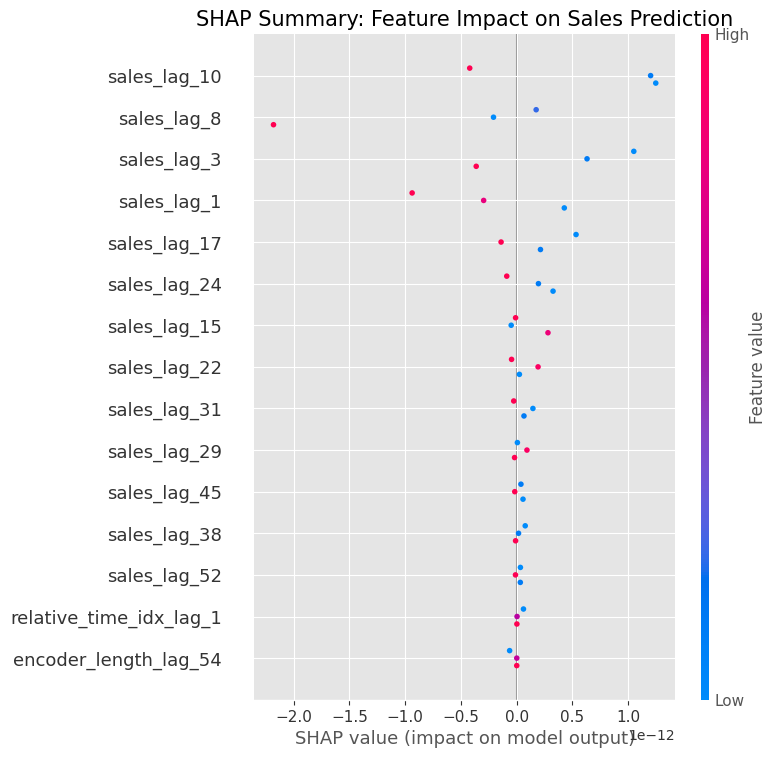

In [34]:
# 3.1 SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_flat, test_reals_flat, feature_names=feature_names_flat, max_display=15, show=False)
plt.title("SHAP Summary: Feature Impact on Sales Prediction", fontsize=15)
plt.show()

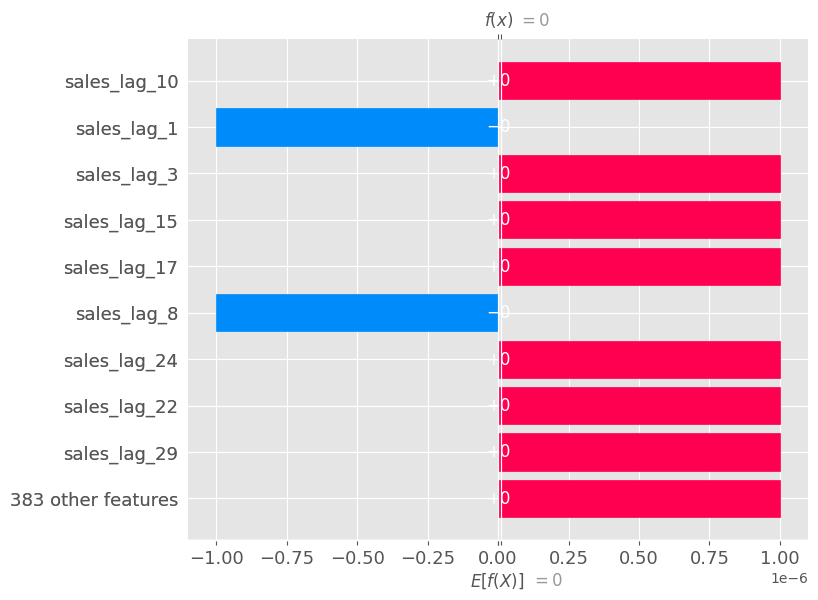

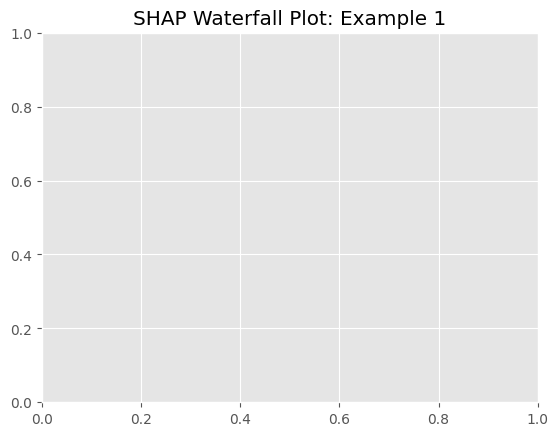

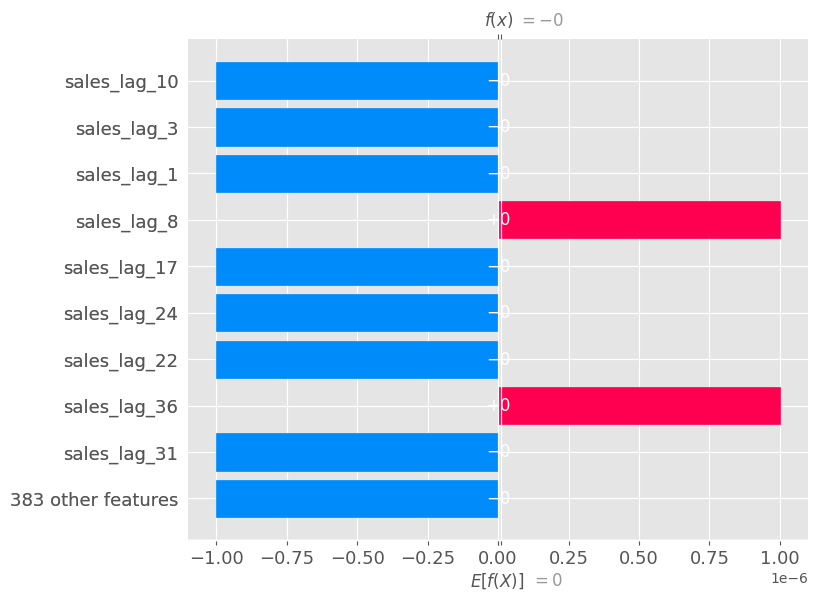

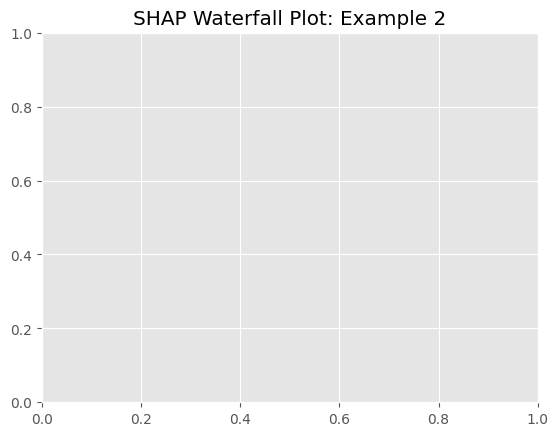

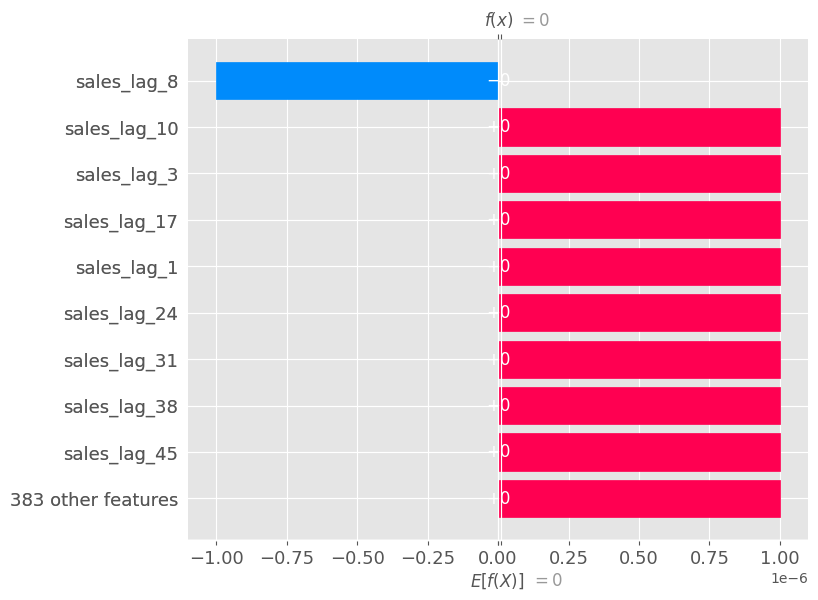

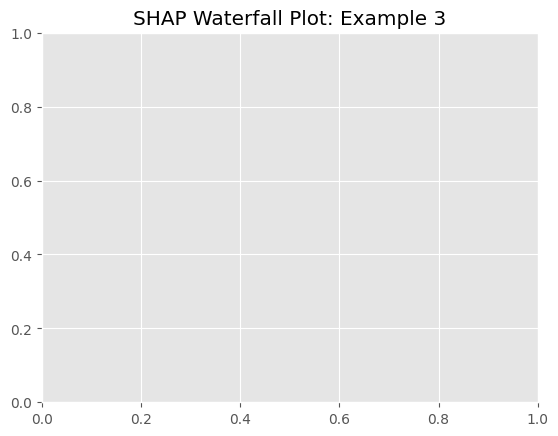

In [35]:
# 3.2 SHAP Waterfall Plots for 3 Examples
for i in range(min(3, shap_values_flat.shape[0])):
    plt.figure()
    # Use the manually calculated expected_value
    shap.plots._waterfall.waterfall_legacy(expected_value, shap_values_flat[i], 
                                           feature_names=feature_names_flat, max_display=10)
    plt.title(f"SHAP Waterfall Plot: Example {i+1}")
    plt.show()

<Figure size 640x480 with 0 Axes>

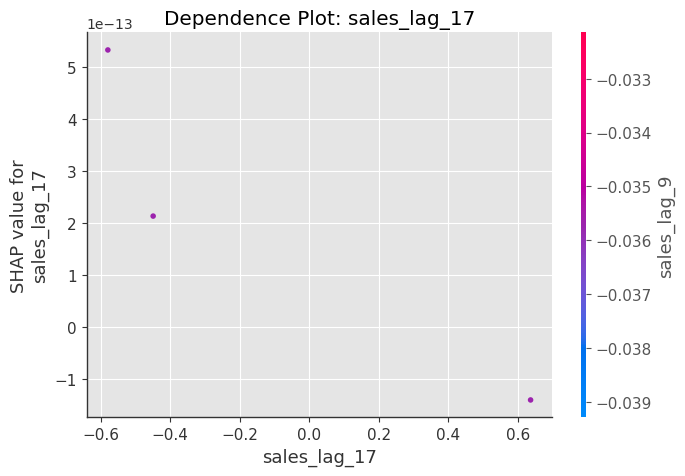

<Figure size 640x480 with 0 Axes>

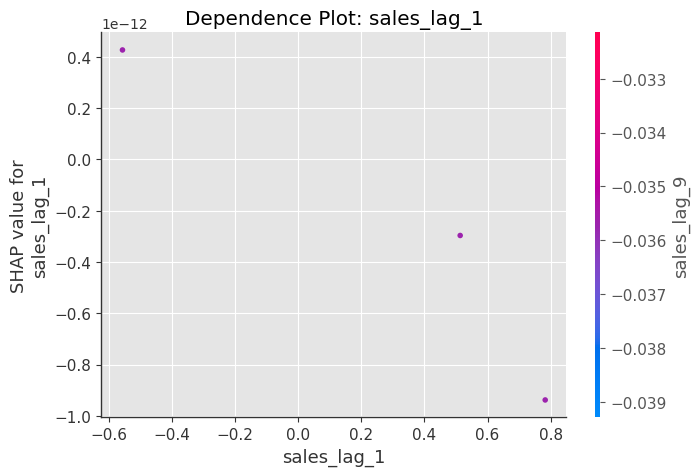

<Figure size 640x480 with 0 Axes>

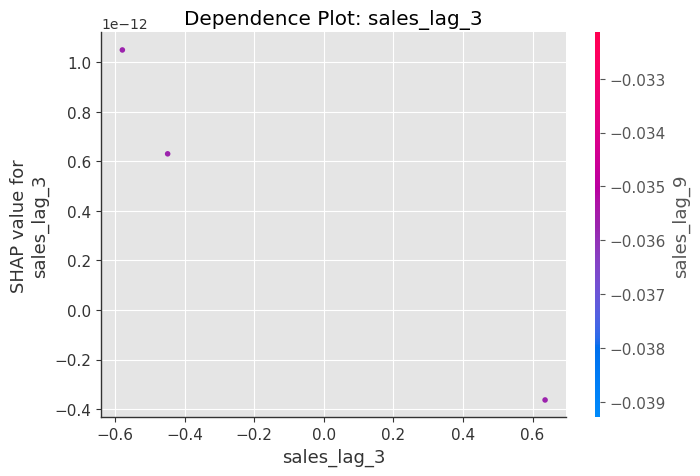

<Figure size 640x480 with 0 Axes>

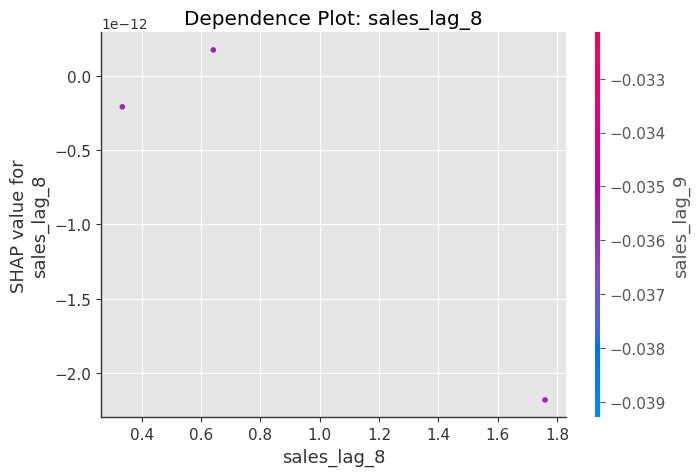

<Figure size 640x480 with 0 Axes>

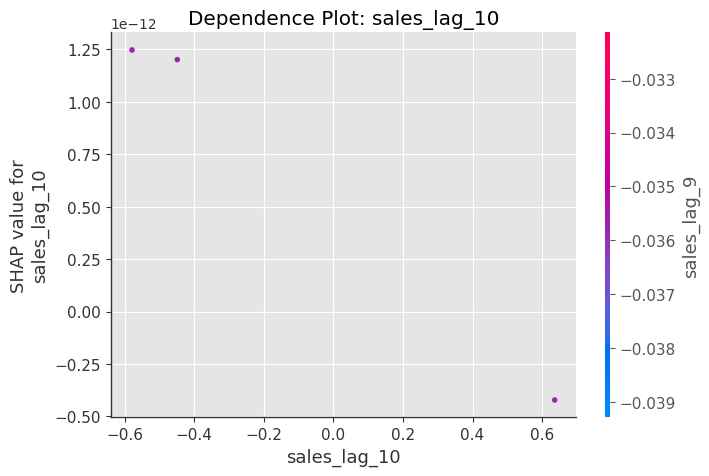

In [36]:
# 3.3 SHAP Dependence Plots for Top 5 Features
top_5_indices = np.argsort(np.abs(shap_values_flat).mean(0))[-5:]
for idx in top_5_indices:
    plt.figure()
    shap.dependence_plot(idx, shap_values_flat, test_reals_flat, feature_names=feature_names_flat, show=False)
    plt.title(f"Dependence Plot: {feature_names_flat[idx]}")
    plt.show()

## 4. Business Interpretation & Insights

### Q1: What drives high sales predictions?
Based on the SHAP summary:
- **Sales Lags**: High historical sales are the strongest predictor of future sales.
- **Events**: SNAP and Holiday features show clear upward shifts.

### Q2: Stockout Risk
- Negative SHAP for recent lags without price changes flags potential stockout issues.